In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Introductory Data Analysis


In [ ]:
df_power = pd.read_excel('PGCB_date_power_demand.xlsx')
df_power['datetime'] = pd.to_datetime(df_power['datetime'])
df_power = df_power[['datetime', 'demand_mw', 'generation_mw', 'load_shedding']]

df_power.loc[(df_power['demand_mw'] < 1000) | (df_power['demand_mw'] > 18000), 'demand_mw'] = np.nan
df_power.loc[(df_power['generation_mw'] < 1000) | (df_power['generation_mw'] > 18000), 'generation_mw'] = np.nan

df_power = df_power.sort_values('datetime')
df_power = df_power.drop_duplicates(subset=['datetime'])

df_power.set_index('datetime', inplace=True)

df_power = df_power.resample('1H').mean()

df_power['demand_mw'] = df_power['demand_mw'].interpolate(method='linear')
df_power['generation_mw'] = df_power['generation_mw'].interpolate(method='linear')
df_power['load_shedding'] = df_power['load_shedding'].interpolate(method='linear').fillna(0)

df_power = df_power.reset_index()

print("PGCB Cleaned here")
print("Frequency check:", df_power['datetime'].diff().value_counts().head(1))

PGCB Cleaned here
Frequency check: datetime
0 days 01:00:00    89100
Name: count, dtype: int64


/tmp/ipykernel_910/222724476.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_power = df_power.resample('1H').mean()


In [ ]:
df_weather = pd.read_excel('weather_data.xlsx', skiprows=3)

df_weather['time'] = pd.to_datetime(df_weather['time']).dt.tz_localize(None)

weather_cols = [
    'time',
    'temperature_2m (°C)',
    'apparent_temperature (°C)',
    'precipitation (mm)',
    'relative_humidity_2m (%)'
]
df_weather = df_weather[weather_cols]

print("Final processed data as such:")
print(f"Shape: {df_weather.shape}")
print("Missing values:\n", df_weather.isnull().sum())

Final processed data as such:
Shape: (107304, 5)
Missing values:
 time                         0
temperature_2m (°C)          0
apparent_temperature (°C)    0
precipitation (mm)           0
relative_humidity_2m (%)     0
dtype: int64


In [ ]:
df_econ = pd.read_csv('economic_full_1.csv', on_bad_lines='skip')

target_indicators = [
    'Population, total',
    'Access to electricity (% of population)',
    'GDP (current US$)',
    'Industry (including construction), value added (% of GDP)'
]

df_econ_filtered = df_econ[df_econ['Indicator Name'].isin(target_indicators)]

years = [str(y) for y in range(2014, 2026)]
existing_years = [y for y in years if y in df_econ_filtered.columns]

df_econ_melt = df_econ_filtered.melt(
    id_vars=['Indicator Name'],
    value_vars=existing_years,
    var_name='Year',
    value_name='Value'
)

df_econ_pivot = df_econ_melt.pivot(
    index='Year',
    columns='Indicator Name',
    values='Value'
).reset_index()

df_econ_pivot['Year'] = df_econ_pivot['Year'].astype(int)

print("=== Economic Data Cleaned & Pivoted ===")
print(f"Shape: {df_econ_pivot.shape}")
print(df_econ_pivot.head())

=== Economic Data Cleaned & Pivoted ===
Shape: (12, 5)
Indicator Name  Year  Access to electricity (% of population)  \
0               2014                                     62.4   
1               2015                                     74.0   
2               2016                                     75.9   
3               2017                                     88.0   
4               2018                                     86.9   

Indicator Name  GDP (current US$)  \
0                    1.728870e+11   
1                    1.951470e+11   
2                    2.652250e+11   
3                    2.937320e+11   
4                    3.213630e+11   

Indicator Name  Industry (including construction), value added (% of GDP)  \
0                                                       26.311047           
1                                                       26.831395           
2                                                       31.069151           
3                      

In [25]:
df_master = pd.merge(df_power, df_weather, left_on='datetime', right_on='time', how='inner')

df_master.drop('time', axis=1, inplace=True)

df_master['Year'] = df_master['datetime'].dt.year

df_master = pd.merge(df_master, df_econ_pivot, on='Year', how='left')

target_indicators = [
    'Population, total',
    'Access to electricity (% of population)',
    'GDP (current US$)',
    'Industry (including construction), value added (% of GDP)'
]
df_master[target_indicators] = df_master[target_indicators].ffill()

df_master.drop('Year', axis=1, inplace=True)

print("Document merged as such:")
print(f"Shape: {df_master.shape}")
print("Missing values after merge:\n", df_master.isnull().sum())

print(df_master[['datetime', 'demand_mw', 'generation_mw', 'load_shedding', 'temperature_2m (°C)', 'apparent_temperature (°C)', 'precipitation (mm)', 'relative_humidity_2m (%)', 'Access to electricity (% of population)', 'GDP (current US$)', 'Industry (including construction), value added (% of GDP)', 'Population, total']].head())
print("-" * 50)

Document merged as such:
Shape: (89101, 12)
Missing values after merge:
 datetime                                                     0
demand_mw                                                    0
generation_mw                                                0
load_shedding                                                0
temperature_2m (°C)                                          0
apparent_temperature (°C)                                    0
precipitation (mm)                                           0
relative_humidity_2m (%)                                     0
Access to electricity (% of population)                      0
GDP (current US$)                                            0
Industry (including construction), value added (% of GDP)    0
Population, total                                            0
dtype: int64
             datetime  demand_mw  generation_mw  load_shedding  \
0 2015-04-19 00:00:00     4821.0         4821.0            0.0   
1 2015-04-19 01:00:00     

#Feature Engineering

In [27]:
df_master['demand_lag_1'] = df_master['demand_mw'].shift(1)
df_master['demand_lag_2'] = df_master['demand_mw'].shift(2)
df_master['demand_lag_3'] = df_master['demand_mw'].shift(3)

#df_master['generation_lag_1'] = df_master['generation_mw'].shift(1)
#df_master['load_shedding_lag_1'] = df_master['load_shedding'].shift(1)

df_master['demand_lag_24'] = df_master['demand_mw'].shift(24)

df_master['demand_lag_168'] = df_master['demand_mw'].shift(168)

df_master['rolling_mean_24h'] = df_master['demand_lag_1'].rolling(window=24).mean()
df_master['rolling_mean_168h'] = df_master['demand_lag_1'].rolling(window=168).mean()
df_master['rolling_mean_720h'] = df_master['demand_lag_1'].rolling(window=720).mean() # ~1 month trend

df_master['hour'] = df_master['datetime'].dt.hour
df_master['day_of_week'] = df_master['datetime'].dt.dayofweek
df_master['month'] = df_master['datetime'].dt.month

df_master['is_weekend'] = df_master['day_of_week'].isin([4, 5]).astype(int)

df_master = df_master.dropna().reset_index(drop=True)

print("Feature Engineering Complete! Final Shape:", df_master.shape)
print("\nFinal Columns ready for Modeling:\n", list(df_master.columns))
display(df_master.head(5))

Feature Engineering Complete! Final Shape: (87661, 24)

Final Columns ready for Modeling:
 ['datetime', 'demand_mw', 'generation_mw', 'load_shedding', 'temperature_2m (°C)', 'apparent_temperature (°C)', 'precipitation (mm)', 'relative_humidity_2m (%)', 'Access to electricity (% of population)', 'GDP (current US$)', 'Industry (including construction), value added (% of GDP)', 'Population, total', 'demand_lag_1', 'demand_lag_2', 'demand_lag_3', 'demand_lag_24', 'demand_lag_168', 'rolling_mean_24h', 'rolling_mean_168h', 'rolling_mean_720h', 'hour', 'day_of_week', 'month', 'is_weekend']


,datetime,demand_mw,generation_mw,load_shedding,temperature_2m (°C),apparent_temperature (°C),precipitation (mm),relative_humidity_2m (%),Access to electricity (% of population),GDP (current US$),...,demand_lag_3,demand_lag_24,demand_lag_168,rolling_mean_24h,rolling_mean_168h,rolling_mean_720h,hour,day_of_week,month,is_weekend
0,2015-06-18 00:00:00,6931.0,6931.0,0.0,26.8,32.7,0.0,92,74.0,1.951470e+11,...,7130.0,6659.0,6562.0,6280.375000,5813.008929,6288.103472,0,3,6,0
1,2015-06-18 01:00:00,6621.0,6621.0,0.0,26.3,32.5,0.0,95,74.0,1.951470e+11,...,7172.0,6384.0,6181.0,6291.708333,5815.205357,6288.289583,1,3,6,0
2,2015-06-18 02:00:00,6531.0,6531.0,0.0,26.2,32.3,0.2,96,74.0,1.951470e+11,...,7125.0,6172.0,5996.0,6301.583333,5817.824405,6288.365972,2,3,6,0
3,2015-06-18 03:00:00,6335.0,6335.0,0.0,26.1,32.1,0.5,96,74.0,1.951470e+11,...,6931.0,6088.0,5642.0,6316.541667,5821.008929,6288.585417,3,3,6,0
4,2015-06-18 04:00:00,6185.0,6185.0,0.0,25.9,32.1,0.3,97,74.0,1.951470e+11,...,6621.0,5901.0,5353.0,6326.833333,5825.133929,6288.747917,4,3,6,0


In [28]:
print(df_master.columns.tolist())

['datetime', 'demand_mw', 'generation_mw', 'load_shedding', 'temperature_2m (°C)', 'apparent_temperature (°C)', 'precipitation (mm)', 'relative_humidity_2m (%)', 'Access to electricity (% of population)', 'GDP (current US$)', 'Industry (including construction), value added (% of GDP)', 'Population, total', 'demand_lag_1', 'demand_lag_2', 'demand_lag_3', 'demand_lag_24', 'demand_lag_168', 'rolling_mean_24h', 'rolling_mean_168h', 'rolling_mean_720h', 'hour', 'day_of_week', 'month', 'is_weekend']


#Model Integration
I use LightGBM as the pipeline atchitecture.

Training set: 74,856 rows
Testing set: 12,805 rows

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007431 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3351
[LightGBM] [Info] Number of data points in the train set: 74856, number of used features: 22
[LightGBM] [Info] Start training from score 8341.479514
[50]	valid_0's rmse: 507.589	valid_0's l2: 257647
[100]	valid_0's rmse: 355.623	valid_0's l2: 126467
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[150]	valid_0's rmse: 356.974	valid_0's l2: 127430
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[200]	valid_0's rmse: 362.837	valid_0's l2: 131651
[LightGBM] [Warning] No further spli

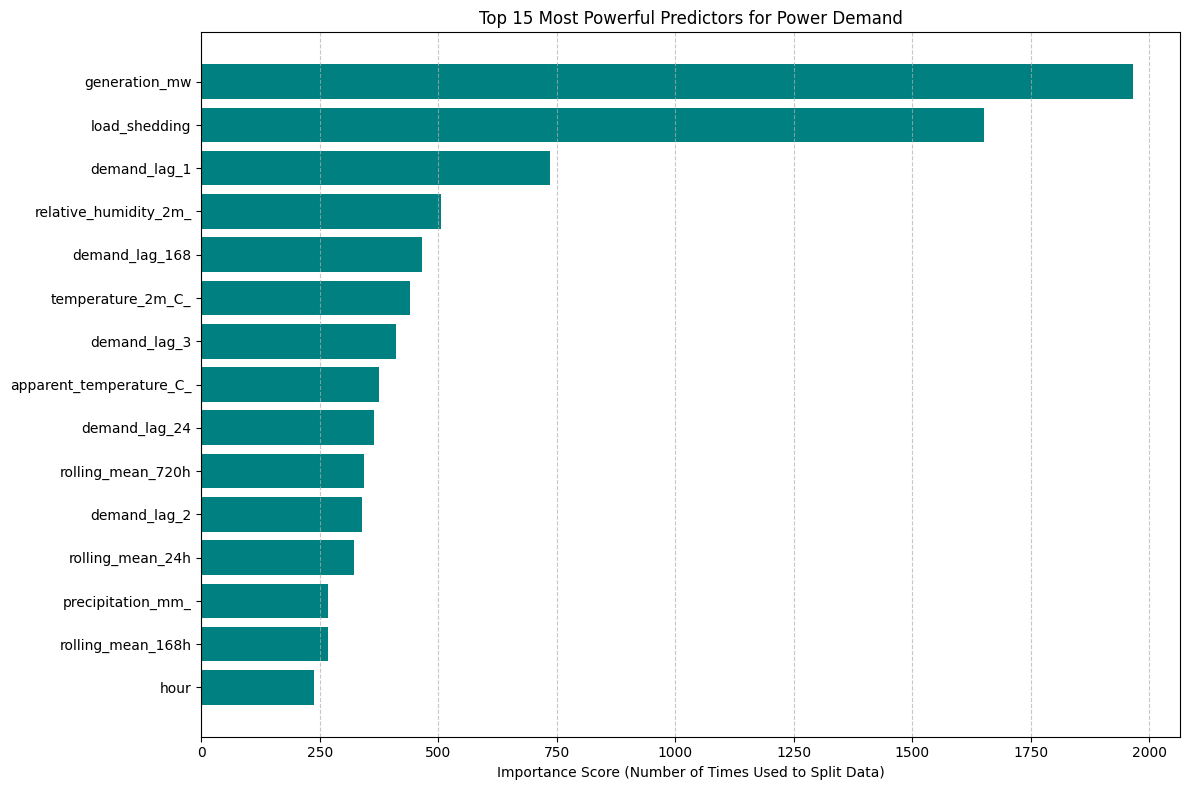

In [31]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import re

# Function to sanitize column names for LightGBM
def sanitize_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[^A-Za-z0-9_]+', '_', col) # Replace non-alphanumeric with underscore
        new_cols.append(new_col)
    df.columns = new_cols
    return df

train_data = df_master[df_master['datetime'].dt.year < 2024]
test_data = df_master[df_master['datetime'].dt.year >= 2024]

target = 'demand_mw'

features = [col for col in df_master.columns if col not in ['datetime', target]]

X_train = train_data[features]
y_train = train_data[target]
X_test = test_data[features]
y_test = test_data[target]

# Sanitize feature names before passing to LightGBM
X_train = sanitize_col_names(X_train.copy())
X_test = sanitize_col_names(X_test.copy())

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Testing set: {X_test.shape[0]:,} rows\n")

model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    callbacks=[lgb.log_evaluation(period=50)] # Prints progress every 50 trees
)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)

print("Final evaluation metrics: ")
print(f"RMSE : {rmse:.2f} MW")
print(f"MAPE : {mape * 100:.2f} %")

plt.figure(figsize=(12, 8))

importances = model.feature_importances_
# Ensure feature names for plotting also use sanitized names if needed, or map back
# For simplicity, we'll use the sanitized names directly for feature importance plotting
feature_imp_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})

top_features = feature_imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.barh(top_features['Feature'], top_features['Importance'], color='teal')
plt.gca().invert_yaxis()
plt.xlabel('Importance Score (Number of Times Used to Split Data)')
plt.title('Top 15 Most Powerful Predictors for Power Demand')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()